In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from transformers import GPT2Model, GPT2Tokenizer
from collections import Counter
import urllib.request

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2Model.from_pretrained("gpt2",
                                   output_attentions=True)
model.eval()

print("Ready!")

c:\Users\devuser3\AppData\Roaming\uv\python\cpython-3.14.3-windows-x86_64-none\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 6646.01it/s]

Ready!


In [2]:

url = "https://www.gutenberg.org/files/2701/2701-0.txt"
with urllib.request.urlopen(url) as f:
    book_text = f.read().decode("utf-8")


book_tokens = tokenizer.encode(book_text[:50000])


token_freq = Counter(book_tokens)
total_tokens = len(book_tokens)

print(f"Total tokens: {total_tokens}")
print(f"Unique tokens: {len(token_freq)}")


print("\nTop 10 most common tokens:")
for token_id, count in token_freq.most_common(10):
    word = tokenizer.decode([token_id])
    print(f"  '{word}': {count} ({count/total_tokens*100:.2f}%)")

Token indices sequence length is longer than the specified maximum sequence length for this model (14309 > 1024). Running this sequence through the model will result in indexing errors


Total tokens: 14309
Unique tokens: 3635

Top 10 most common tokens:
  '
': 965 (6.74%)
  ',': 618 (4.32%)
  '.': 587 (4.10%)
  ' ': 520 (3.63%)
  ' the': 460 (3.21%)
  ' of': 289 (2.02%)
  '�': 230 (1.61%)
  ' and': 228 (1.59%)
  ' a': 227 (1.59%)
  ' in': 171 (1.20%)


In [3]:
text = "The king ruled the kingdom and the queen lived in the castle"
inputs = tokenizer(text, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
token_ids = inputs['input_ids'][0].tolist()

with torch.no_grad():
    outputs = model(**inputs)

attn = outputs.attentions[0][0].mean(dim=0)  # [n_tokens, n_tokens]
avg_attn_received = attn.mean(dim=0).numpy()  # Har token ko kitni mili

# Har token ki frequency
freqs = [token_freq.get(tid, 0) / total_tokens 
         for tid in token_ids]

print(f"{'Token':<12} {'Frequency':<12} {'Avg Attention'}")
print("-"*38)
for token, freq, attn_val in zip(tokens, freqs, avg_attn_received):
    print(f"{token:<12} {freq:<12.4f} {attn_val:.4f}")

Token        Frequency    Avg Attention
--------------------------------------
The          0.0018       0.3151
Ġking        0.0003       0.1091
Ġruled       0.0000       0.0977
Ġthe         0.0321       0.0865
Ġkingdom     0.0000       0.0731
Ġand         0.0159       0.0665
Ġthe         0.0321       0.0492
Ġqueen       0.0000       0.0573
Ġlived       0.0000       0.0517
Ġin          0.0120       0.0392
Ġthe         0.0321       0.0202
Ġcastle      0.0000       0.0343


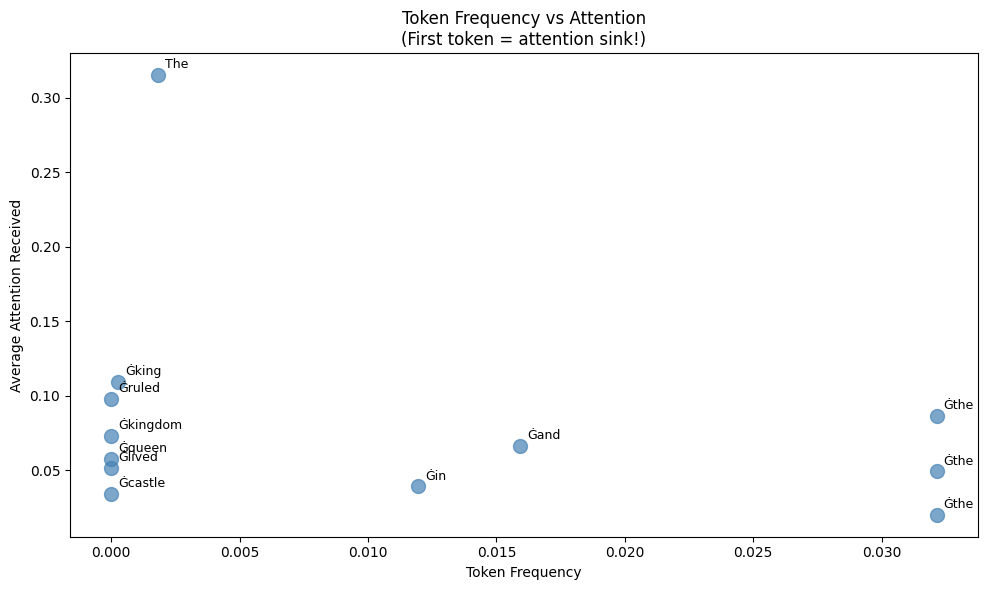

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(freqs, avg_attn_received, 
           color="steelblue", s=100, alpha=0.7)

for token, freq, attn_val in zip(tokens, freqs, avg_attn_received):
    ax.annotate(token,
               (freq, attn_val),
               textcoords="offset points",
               xytext=(5, 5), fontsize=9)

ax.set_xlabel("Token Frequency")
ax.set_ylabel("Average Attention Received")
ax.set_title("Token Frequency vs Attention\n"
             "(First token = attention sink!)")

plt.tight_layout()
plt.show()

* The first token (“The”) receives the most attention — an “attention sink”
* There is no direct relationship between frequency and attention
* Position is more important than frequency for attention
* This “attention sink” phenomenon has been observed in real LLMs as well
